In [1]:
# Cell 1 - Environment check
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout if r.returncode == 0 else 'WARNING: No GPU detected')


Fri Jun 26 04:48:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:B3:00.0 Off |                    0 |
| N/A   35C    P0             51W /  300W |       0MiB /  39936MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [4]:
pip install -q pandas numpy matplotlib psutil tqdm datasets tiktoken

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Cell 2 - Imports, deterministic CUDA, config
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import sys, json, time, math, shutil, random, socket, platform, subprocess
import datetime as dt
import gc
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, Image as IPImage

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.use_deterministic_algorithms(True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    GPU_NAME = torch.cuda.get_device_name(0)
else:
    GPU_NAME = "cpu"

PRECISION = "bf16"
if PRECISION == "bf16" and DEVICE == "cuda" and torch.cuda.is_bf16_supported():
    AMP_DTYPE = torch.bfloat16
else:
    AMP_DTYPE = torch.float32
USE_AMP = DEVICE == "cuda" and AMP_DTYPE in (torch.float16, torch.bfloat16)
SCALER_ENABLED = False  # bf16 doesn't need GradScaler

PROJECT_ID = "residual_124m_corrected_v1"
EXP_NAME   = "AttnOnly_std_seed42"
SEED       = 42

LOCAL_ROOT = Path("/workspace/residual_gain_runs")
PROJECT_DIR = LOCAL_ROOT / PROJECT_ID
DATA_DIR   = PROJECT_DIR / "data"
RUN_DIR    = PROJECT_DIR / "runs" / EXP_NAME
CKPT_DIR   = RUN_DIR / "checkpoints"
FIG_DIR    = RUN_DIR / "figures"
TABLE_DIR  = RUN_DIR / "tables"
META_DIR   = RUN_DIR / "metadata"
for d in [DATA_DIR, CKPT_DIR, FIG_DIR, TABLE_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

N_LAYER, N_EMBD, N_HEAD, BLOCK_SIZE, DROPOUT = 12, 768, 12, 1024, 0.10
BATCH_SIZE, GRAD_ACCUM = 16, 8
MAX_ITERS, EVAL_INTERVAL, EVAL_BATCHES = 20000, 500, 50
CHECKPOINT_INTERVAL, DASHBOARD_INTERVAL = 500, 500
LEARNING_RATE, MIN_LR, WARMUP_ITERS = 6e-4, 6e-5, 2000
WEIGHT_DECAY, BETA1, BETA2, GRAD_CLIP = 0.10, 0.9, 0.95, 1.0
USE_GRAD_CHECKPOINTING = True
OWT_TARGET_DOCS, OWT_VAL_EVERY_N_DOCS = 100_000, 10_000

print(f"Device: {DEVICE} | GPU: {GPU_NAME} | torch: {torch.__version__} | cuda: {torch.version.cuda}")
print(f"Experiment: {EXP_NAME} | seed: {SEED} | deterministic mode: ON")
print(f"Run dir: {RUN_DIR}")


Device: cuda | GPU: NVIDIA A100-SXM4-40GB | torch: 2.12.0+cu130 | cuda: 13.0
Experiment: AttnOnly_std_seed42 | seed: 42 | deterministic mode: ON
Run dir: /workspace/residual_gain_runs/residual_124m_corrected_v1/runs/AttnOnly_std_seed42


In [6]:
from pathlib import Path

p = Path("/workspace/residual_gain_runs/residual_124m_corrected_v1/runs/AttnOnly_std_seed42/checkpoints/latest.pt")
print("Exists:", p.exists())
print("Path:", p)

Exists: True
Path: /workspace/residual_gain_runs/residual_124m_corrected_v1/runs/AttnOnly_std_seed42/checkpoints/latest.pt


In [7]:
from pathlib import Path
import torch

ckpt_path = Path("/workspace/residual_gain_runs/residual_124m_corrected_v1/runs/AttnOnly_std_seed42/checkpoints/latest.pt")

print("Exists:", ckpt_path.exists())
print("Size MB:", ckpt_path.stat().st_size / 1024 / 1024)

ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

print("Checkpoint keys:", ckpt.keys())
print("Checkpoint step:", ckpt.get("step"))
print("Best val:", ckpt.get("best_val"))
print("Best step:", ckpt.get("best_step"))
print("History length:", len(ckpt.get("history", [])))

if ckpt.get("history"):
    print("Last history row:", ckpt["history"][-1])

Exists: True
Size MB: 1423.2919416427612
Checkpoint keys: dict_keys(['step', 'model_state', 'optimizer_state', 'history', 'best_val', 'best_step'])
Checkpoint step: 20000
Best val: 7.586435270309448
Best step: 3000
History length: 41
Last history row: {'step': 20000, 'lr': 6e-05, 'train_loss': 7.557329797744751, 'val_loss': 7.5947630500793455, 'val_ppl': 1987.758796405071, 'diag': {'hidden_norm_by_layer': [82.65760040283203, 37.338623046875, 31.722476959228516, 10.052618026733398, 13.878595352172852, 32.088462829589844, 13.996706008911133, 4.079293251037598, 25.293067932128906, 38.73095703125, 391.5108642578125, 5536.322265625], 'attn_norm_by_layer': [20.004112243652344, 64.67056274414062, 18.832712173461914, 18.810209274291992, 32.44628143310547, 13.520366668701172, 3.072539806365967, 5.659605979919434, 21.484699249267578, 6.468676567077637, 31.351469039916992, 474.542236328125], 'mlp_norm_by_layer': [82.65760040283203, 37.338623046875, 31.722476959228516, 10.052618026733398, 13.87859

In [8]:
# Cell 1 - Install and verify environment
import os
import sys
import json
import time
import math
import shutil
import random
import socket
import pathlib
import platform
import subprocess
from pathlib import Path

REQUIRED_PACKAGES = [
    "torch", "numpy", "pandas", "matplotlib", "psutil", "tqdm", "datasets", "tiktoken"
]

def run_cmd(cmd, check=False, capture=True):
    result = subprocess.run(cmd, shell=True, text=True,
                            stdout=subprocess.PIPE if capture else None,
                            stderr=subprocess.STDOUT if capture else None)
    if check and result.returncode != 0:
        raise RuntimeError(result.stdout)
    return result

missing = []
for package in REQUIRED_PACKAGES:
    import_name = package
    try:
        __import__(import_name)
    except Exception:
        missing.append(package)

if missing:
    print("Installing missing packages:", missing)
    run_cmd(f"{sys.executable} -m pip install -q " + " ".join(missing), check=True, capture=False)

if shutil.which("rclone") is None:
    print("rclone not found. Installing rclone...")
    install = run_cmd("curl -fsSL https://rclone.org/install.sh | bash", check=False, capture=True)
    print(install.stdout[-1000:] if install.stdout else "")
else:
    print("rclone found:", shutil.which("rclone"))

print("Python:", sys.version.split()[0])
try:
    gpu = run_cmd("nvidia-smi --query-gpu=name,memory.total --format=csv,noheader", capture=True)
    print("GPU:", gpu.stdout.strip() if gpu.stdout else "No GPU output")
except Exception as exc:
    print("GPU check failed:", exc)


rclone found: /usr/bin/rclone
Python: 3.12.13
GPU: NVIDIA A100-SXM4-40GB, 39936 MiB


In [9]:
# Cell 3 - Dataset (OpenWebText, BPE) -- loads from cache if already present
import tiktoken

def load_memmap(path, dtype="uint16"):
    return np.memmap(path, dtype=dtype, mode="r")

DATASET_DIR = DATA_DIR / f"openwebtext_bpe_{BLOCK_SIZE}"
DATASET_DIR.mkdir(parents=True, exist_ok=True)
train_path = DATASET_DIR / "train.bin"
val_path   = DATASET_DIR / "val.bin"

enc = tiktoken.get_encoding("gpt2")
VOCAB_SIZE = enc.n_vocab

if train_path.exists() and val_path.exists():
    print("OpenWebText already cached -- loading from disk")
else:
    from datasets import load_dataset
    print("Streaming and tokenizing OpenWebText (first time only, will take a while)...")
    ds = load_dataset("Skylion007/openwebtext", split="train", streaming=True)
    train_buf, val_buf = [], []
    train_count = val_count = 0
    FLUSH_EVERY = 10_000
    for doc in ds:
        tokens = enc.encode_ordinary(doc["text"])
        if train_count % OWT_VAL_EVERY_N_DOCS == 0 and train_count > 0:
            val_buf.extend(tokens); val_count += 1
        else:
            train_buf.extend(tokens); train_count += 1
        if len(train_buf) >= FLUSH_EVERY * 100:
            arr = np.array(train_buf, dtype=np.uint16)
            with open(train_path, "ab") as f: f.write(arr.tobytes())
            train_buf = []
        if len(val_buf) >= FLUSH_EVERY * 10:
            arr = np.array(val_buf, dtype=np.uint16)
            with open(val_path, "ab") as f: f.write(arr.tobytes())
            val_buf = []
        total = train_count + val_count
        if total % 5000 == 0:
            print(f"  docs={total:,}")
        if total >= OWT_TARGET_DOCS:
            break
    if train_buf:
        arr = np.array(train_buf, dtype=np.uint16)
        with open(train_path, "ab") as f: f.write(arr.tobytes())
    if val_buf:
        arr = np.array(val_buf, dtype=np.uint16)
        with open(val_path, "ab") as f: f.write(arr.tobytes())
    print("Dataset ready.")

train_data_mm = load_memmap(str(train_path))
val_data_mm   = load_memmap(str(val_path))
print(f"Train tokens: {len(train_data_mm)/1e6:.1f}M | Val tokens: {len(val_data_mm)/1e6:.1f}M | vocab={VOCAB_SIZE}")


Streaming and tokenizing OpenWebText (first time only, will take a while)...


README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

  docs=5,000
  docs=10,000
  docs=15,000
  docs=20,000
  docs=25,000
  docs=30,000
  docs=35,000
  docs=40,000
  docs=45,000
  docs=50,000
  docs=55,000
  docs=60,000
  docs=65,000
  docs=70,000
  docs=75,000
  docs=80,000
  docs=85,000
  docs=90,000
  docs=95,000
  docs=100,000
Dataset ready.
Train tokens: 11.1M | Val tokens: 101.7M | vocab=50257


In [10]:
# Cell 4 - Batcher with fixed validation batches (seed 99991)
class SequenceBatcher:
    def __init__(self, train_mm, val_mm, block_size, batch_size, device, seed=1337):
        self.train_mm = train_mm
        self.val_mm = val_mm
        self.block_size = block_size
        self.batch_size = batch_size
        self.device = device
        self.generator = torch.Generator(device="cpu")
        self.generator.manual_seed(seed)
        self.fixed_val_batches = []

    def _offsets(self, length, n):
        hi = max(1, length - self.block_size - 1)
        return torch.randint(0, hi, (n,), generator=self.generator)

    def sample(self, split):
        src = self.train_mm if split == "train" else self.val_mm
        ix = self._offsets(len(src), self.batch_size)
        x = np.stack([src[i:i+self.block_size].astype(np.int64) for i in ix])
        y = np.stack([src[i+1:i+self.block_size+1].astype(np.int64) for i in ix])
        return (torch.from_numpy(x).to(self.device, non_blocking=True),
                torch.from_numpy(y).to(self.device, non_blocking=True))

    def build_fixed_val_batches(self, count):
        old_state = self.generator.get_state()
        self.generator.manual_seed(99991)
        self.fixed_val_batches = [self.sample("val") for _ in range(count)]
        self.generator.set_state(old_state)
        print(f"Fixed validation batches: {len(self.fixed_val_batches)} (seed=99991)")

BATCHER = SequenceBatcher(train_data_mm, val_data_mm, BLOCK_SIZE, BATCH_SIZE, DEVICE, seed=1337)
BATCHER.build_fixed_val_batches(EVAL_BATCHES)


Fixed validation batches: 50 (seed=99991)


In [11]:
# Cell 5 - Model (AttnOnly: attention skip kept, MLP skip removed)
@dataclass
class ResidualSwitch:
    use_attention_skip: bool = True
    use_mlp_skip: bool = True

class CausalAttentionLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.qkv = nn.Linear(N_EMBD, 3 * N_EMBD, bias=False)
        self.out = nn.Linear(N_EMBD, N_EMBD, bias=False)
        self.drop = nn.Dropout(DROPOUT)
        self.n_head = N_HEAD
        self.head_dim = N_EMBD // N_HEAD

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, dropout_p=self.drop.p if self.training else 0.0, is_causal=True)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.drop(self.out(y))

class TokenMixerMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.up = nn.Linear(N_EMBD, 4 * N_EMBD, bias=False)
        self.down = nn.Linear(4 * N_EMBD, N_EMBD, bias=False)
        self.drop = nn.Dropout(DROPOUT)
        self.latest_dead_frac = None

    def forward(self, x):
        h = F.gelu(self.up(x))
        if not self.training:
            self.latest_dead_frac = float((h.detach() <= 0).float().mean().cpu())
        return self.drop(self.down(h))

class ResidualBlock(nn.Module):
    def __init__(self, switch: ResidualSwitch):
        super().__init__()
        self.switch = switch
        self.ln1 = nn.LayerNorm(N_EMBD)
        self.ln2 = nn.LayerNorm(N_EMBD)
        self.attn = CausalAttentionLayer()
        self.mlp = TokenMixerMLP()
        self.latest_hidden_norm = None
        self.latest_attn_norm = None
        self.latest_mlp_norm = None

    def forward(self, x):
        a = self.attn(self.ln1(x))
        if not self.training:
            self.latest_attn_norm = float(a.detach().norm(dim=-1).mean().cpu())
        x = x + a if self.switch.use_attention_skip else a
        m = self.mlp(self.ln2(x))
        if not self.training:
            self.latest_mlp_norm = float(m.detach().norm(dim=-1).mean().cpu())
        x = x + m if self.switch.use_mlp_skip else m
        if not self.training:
            self.latest_hidden_norm = float(x.detach().norm(dim=-1).mean().cpu())
        return x

class ResidualGPT(nn.Module):
    def __init__(self, switch: ResidualSwitch):
        super().__init__()
        self.switch = switch
        self.token_embed = nn.Embedding(VOCAB_SIZE, N_EMBD)
        self.pos_embed = nn.Embedding(BLOCK_SIZE, N_EMBD)
        self.drop = nn.Dropout(DROPOUT)
        self.blocks = nn.ModuleList([ResidualBlock(switch) for _ in range(N_LAYER)])
        self.ln_f = nn.LayerNorm(N_EMBD)
        self.lm_head = nn.Linear(N_EMBD, VOCAB_SIZE, bias=False)
        self.lm_head.weight = self.token_embed.weight
        self.apply(self._init_weights)
        scale = 0.02 / math.sqrt(2 * N_LAYER)
        for name, p in self.named_parameters():
            if name.endswith("attn.out.weight") or name.endswith("mlp.down.weight"):
                nn.init.normal_(p, mean=0.0, std=scale)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.token_embed(idx) + self.pos_embed(pos))
        for block in self.blocks:
            if USE_GRAD_CHECKPOINTING and self.training:
                x = torch.utils.checkpoint.checkpoint(block, x, use_reentrant=False)
            else:
                x = block(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss

    def param_count(self):
        return sum(p.numel() for p in self.parameters())

    def diagnostics(self):
        return {
            "hidden_norm_by_layer": [b.latest_hidden_norm for b in self.blocks],
            "attn_norm_by_layer": [b.latest_attn_norm for b in self.blocks],
            "mlp_norm_by_layer": [b.latest_mlp_norm for b in self.blocks],
            "dead_frac_by_layer": [b.mlp.latest_dead_frac for b in self.blocks],
        }

ATTNONLY_SWITCH = ResidualSwitch(use_attention_skip=True, use_mlp_skip=False)
_test = ResidualGPT(ATTNONLY_SWITCH)
print(f"Parameter count: {_test.param_count()/1e6:.2f}M")
del _test
if DEVICE == "cuda":
    torch.cuda.empty_cache()


Parameter count: 124.36M


In [12]:
# Cell 6 - Training helpers
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(seed)

def lr_at(step):
    if step < WARMUP_ITERS:
        return LEARNING_RATE * (step + 1) / WARMUP_ITERS
    if step >= MAX_ITERS:
        return MIN_LR
    progress = (step - WARMUP_ITERS) / max(1, MAX_ITERS - WARMUP_ITERS)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return MIN_LR + cosine * (LEARNING_RATE - MIN_LR)

@torch.no_grad()
def eval_loss_and_diag(model):
    model.eval()
    train_losses, val_losses = [], []
    for _ in range(EVAL_BATCHES):
        xb, yb = BATCHER.sample("train")
        _, loss = model(xb, yb)
        train_losses.append(float(loss.detach().cpu()))
    for xb, yb in BATCHER.fixed_val_batches[:EVAL_BATCHES]:
        _, loss = model(xb, yb)
        val_losses.append(float(loss.detach().cpu()))
    diag = model.diagnostics()
    model.train()
    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))
    return train_loss, val_loss, float(math.exp(min(val_loss, 20.0))), diag

def make_optimizer(model):
    decay = [p for n, p in model.named_parameters() if p.ndim >= 2]
    no_decay = [p for n, p in model.named_parameters() if p.ndim < 2]
    return torch.optim.AdamW(
        [{"params": decay, "weight_decay": WEIGHT_DECAY},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=LEARNING_RATE, betas=(BETA1, BETA2))

print("Training helpers ready")


Training helpers ready


In [13]:
# Cell 7 - Save helpers (checkpoint + history + dashboard)
def atomic_save(obj, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    tmp.replace(path)

def atomic_write_text(path, text):
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(text, encoding="utf-8")
    tmp.replace(path)

def save_history(history):
    (TABLE_DIR / "history.jsonl").write_text(
        "\n".join(json.dumps(r) for r in history), encoding="utf-8")
    pd.DataFrame(history).to_csv(TABLE_DIR / "history.csv", index=False)

def load_checkpoint_if_available(model, optimizer):
    ckpt_path = CKPT_DIR / "latest.pt"
    if not ckpt_path.exists():
        return 0, [], float("inf"), -1
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    print(f"Resumed from step {ckpt['step']}, best_val={ckpt['best_val']:.6f}")
    return ckpt["step"], ckpt["history"], ckpt["best_val"], ckpt["best_step"]

def save_checkpoint(model, optimizer, step, history, best_val, best_step, is_best):
    state = {
        "step": step, "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "history": history, "best_val": best_val, "best_step": best_step,
    }
    atomic_save(state, CKPT_DIR / "latest.pt")
    if is_best:
        atomic_save(state, CKPT_DIR / "best.pt")

print("Save helpers ready")


Save helpers ready


In [14]:
# Cell 8 - Live dashboard (visuals during training)
def make_dashboard(history, out_path, show=True):
    if not history:
        return
    df = pd.DataFrame(history)
    step = int(df["step"].iloc[-1])
    best_val = float(df["val_loss"].min())
    best_idx = int(df["val_loss"].idxmin())

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    ax = axes[0, 0]
    ax.plot(df["step"], df["train_loss"], label="train", color="#2196F3", lw=1.8)
    ax.plot(df["step"], df["val_loss"], label="val", color="#FF9800", lw=1.8)
    ax.scatter([df.loc[best_idx, "step"]], [best_val], color="#F44336", zorder=5, s=80, label=f"best {best_val:.4f}")
    ax.set_title("Loss curves", fontweight="bold"); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[0, 1]
    ax.plot(df["step"], df["val_ppl"], color="#9C27B0", lw=1.8)
    ax.set_yscale("log"); ax.set_title("Validation PPL", fontweight="bold"); ax.grid(alpha=0.3)

    ax = axes[0, 2]
    ax.plot(df["step"], df["lr"], color="#009688", lw=1.8)
    ax.set_title("Learning rate", fontweight="bold"); ax.grid(alpha=0.3)

    ax = axes[1, 0]
    ax.plot(df["step"], df["val_loss"] - df["train_loss"], color="#607D8B", lw=1.5)
    ax.axhline(0, color="#333", lw=1)
    ax.set_title("Val - Train gap", fontweight="bold"); ax.grid(alpha=0.3)

    ax = axes[1, 1]
    latest_diag = history[-1].get("diag", {})
    hidden = latest_diag.get("hidden_norm_by_layer") or []
    if hidden:
        ax.bar(range(len(hidden)), hidden, color="#3F51B5", alpha=0.8)
    ax.set_title(f"Hidden norm by layer (step {step})", fontweight="bold"); ax.grid(alpha=0.3, axis="y")

    ax = axes[1, 2]
    dead = latest_diag.get("dead_frac_by_layer") or []
    if dead:
        ax.bar(range(len(dead)), [d*100 for d in dead], color="#F44336", alpha=0.8)
    ax.set_ylim(0, 100)
    ax.set_title(f"Dead neurons % by layer (step {step})", fontweight="bold"); ax.grid(alpha=0.3, axis="y")

    fig.suptitle(f"AttnOnly_std_seed42 | step {step:,}/{MAX_ITERS:,} | best val {best_val:.4f}",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    if show:
        clear_output(wait=True)
        display(IPImage(filename=str(out_path)))
    plt.close(fig)

print("Dashboard ready")


Dashboard ready


In [ ]:
# Cell 9 - Sanity check (300 steps only, before committing to the full run)
set_seed(SEED)
_sanity_model = ResidualGPT(ATTNONLY_SWITCH).to(DEVICE)
_sanity_opt = make_optimizer(_sanity_model)
for s in range(1, 301):
    lr = lr_at(s)
    for g in _sanity_opt.param_groups: g["lr"] = lr
    _sanity_opt.zero_grad(set_to_none=True)
    for _ in range(GRAD_ACCUM):
        xb, yb = BATCHER.sample("train")
        ctx = torch.autocast(device_type="cuda", dtype=AMP_DTYPE) if USE_AMP else torch.enable_grad()
        with ctx:
            _, loss = _sanity_model(xb, yb)
        (loss / GRAD_ACCUM).backward()
    torch.nn.utils.clip_grad_norm_(_sanity_model.parameters(), GRAD_CLIP)
    _sanity_opt.step()
_, val0, _, _ = eval_loss_and_diag(_sanity_model)
print(f"Sanity check val_loss @ step 300: {val0:.4f}")
print("Should be well below ln(50257) =~ 10.8 (random init level) and descending.")
del _sanity_model, _sanity_opt
if DEVICE == "cuda": torch.cuda.empty_cache()


In [15]:
# Cell 10 - THE FULL RUN: AttnOnly_std, seed 42, 124M, 20000 steps
# Saves checkpoint + history + dashboard every EVAL_INTERVAL steps.
# Resumable: re-running this cell after an interruption picks up from latest.pt.

set_seed(SEED)
start_step, history, best_val, best_step = load_checkpoint_if_available(None, None) if False else (0, [], float("inf"), -1)

model = ResidualGPT(ATTNONLY_SWITCH).to(DEVICE)
optimizer = make_optimizer(model)

start_step, history, best_val, best_step = load_checkpoint_if_available(model, optimizer)

if start_step == 0 and not history:
    train0, val0, ppl0, diag0 = eval_loss_and_diag(model)
    history.append({"step": 0, "lr": lr_at(0), "train_loss": train0, "val_loss": val0, "val_ppl": ppl0, "diag": diag0})
    best_val, best_step = val0, 0
    save_history(history)
    save_checkpoint(model, optimizer, 0, history, best_val, best_step, is_best=True)

model.train()
started = time.time()
for step in range(start_step + 1, MAX_ITERS + 1):
    lr = lr_at(step)
    for g in optimizer.param_groups: g["lr"] = lr
    optimizer.zero_grad(set_to_none=True)
    for _ in range(GRAD_ACCUM):
        xb, yb = BATCHER.sample("train")
        ctx = torch.autocast(device_type="cuda", dtype=AMP_DTYPE) if USE_AMP else torch.enable_grad()
        with ctx:
            _, loss = model(xb, yb)
        (loss / GRAD_ACCUM).backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    optimizer.step()

    should_eval = (step % EVAL_INTERVAL == 0) or (step == MAX_ITERS)
    if should_eval:
        train_loss, val_loss, val_ppl, diag = eval_loss_and_diag(model)
        is_best = val_loss < best_val
        if is_best:
            best_val, best_step = val_loss, step
        history.append({"step": step, "lr": lr, "train_loss": train_loss, "val_loss": val_loss, "val_ppl": val_ppl, "diag": diag})
        save_history(history)
        elapsed = time.time() - started
        print(f"step={step:,} train={train_loss:.4f} val={val_loss:.4f} best={best_val:.4f}@{best_step} ({elapsed:.0f}s)")
        save_checkpoint(model, optimizer, step, history, best_val, best_step, is_best=is_best)
        make_dashboard(history, FIG_DIR / "dashboard_latest.png", show=True)

print("\nTraining complete.")


Resumed from step 20000, best_val=7.586435

Training complete.


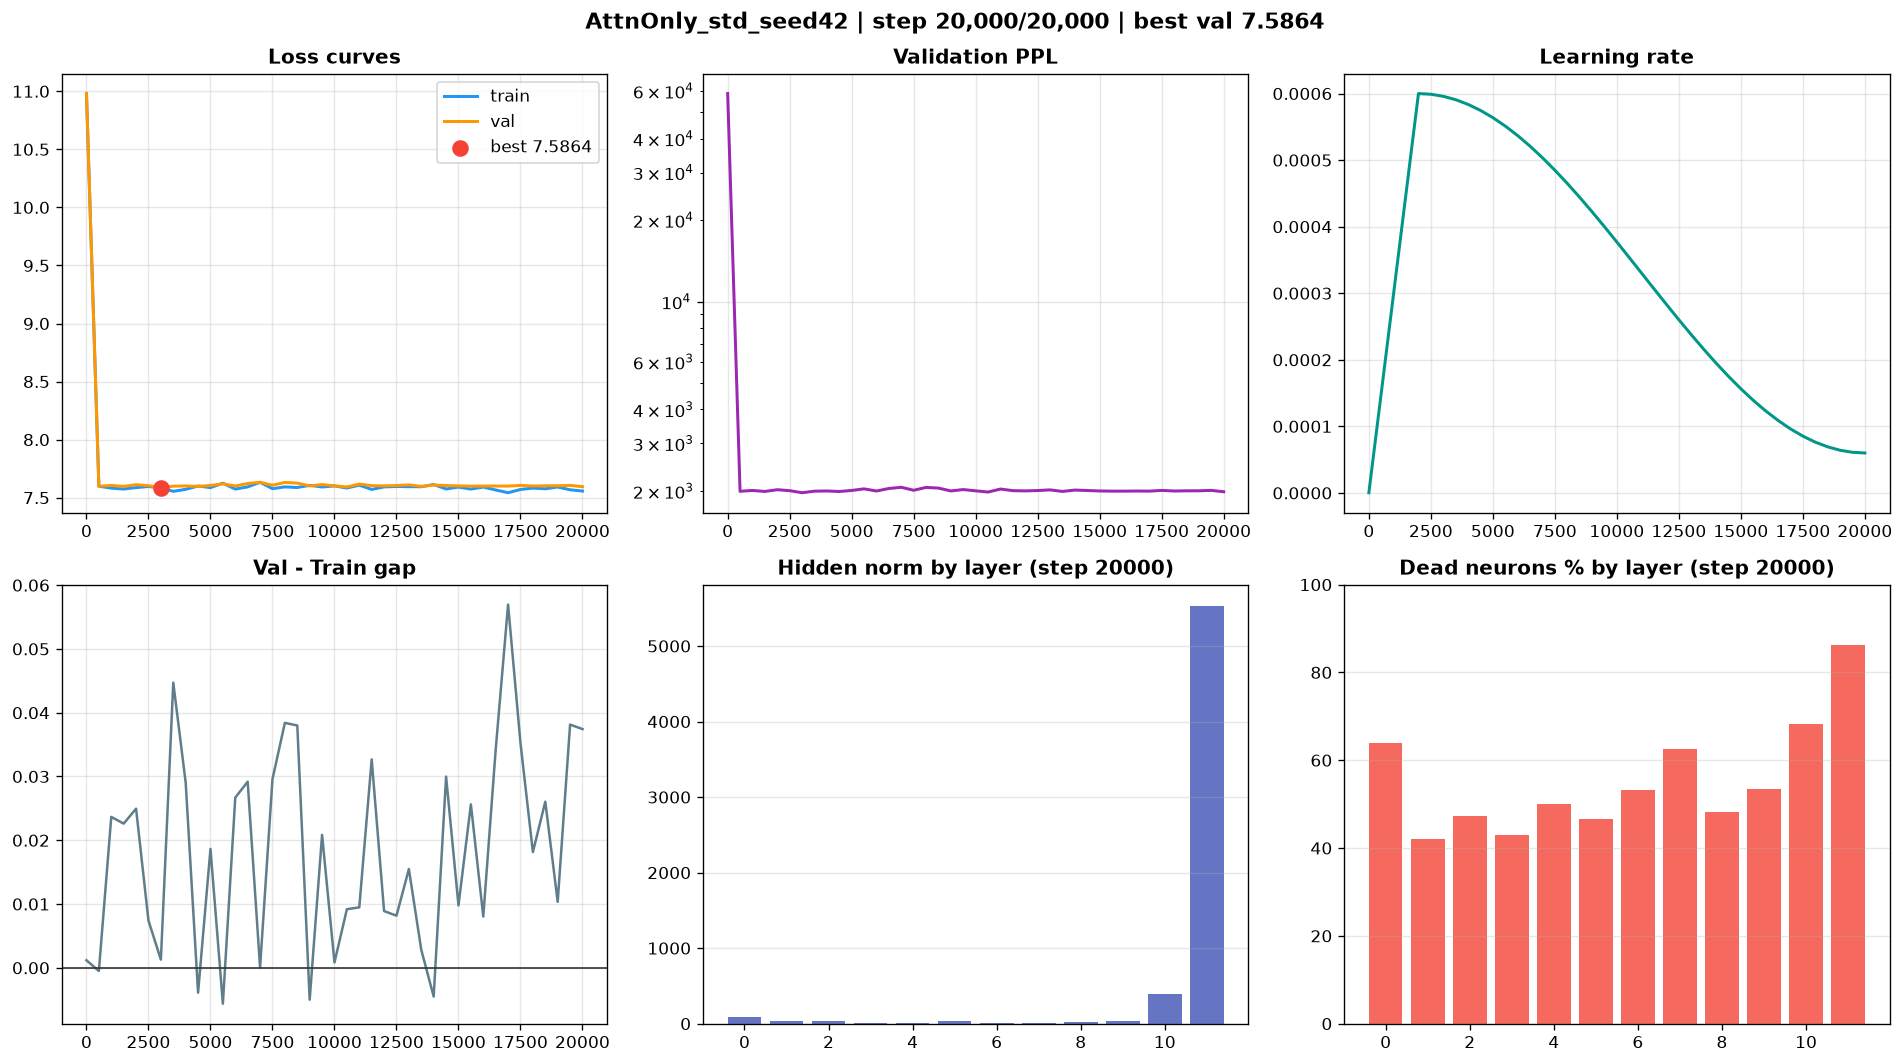

Saved summary.json and final_dashboard.png
{
  "name": "AttnOnly_std_seed42",
  "seed": 42,
  "use_attention_skip": true,
  "use_mlp_skip": false,
  "best_val_loss": 7.586435270309448,
  "best_step": 3000,
  "final_step": 20000,
  "final_val_loss": 7.5947630500793455,
  "num_history_rows": 41,
  "run_dir": "/workspace/residual_gain_runs/residual_124m_corrected_v1/runs/AttnOnly_std_seed42",
  "complete": true
}


In [16]:
# Cell 11 - Save final summary + final dashboard
summary = {
    "name": EXP_NAME, "seed": SEED, "use_attention_skip": True, "use_mlp_skip": False,
    "best_val_loss": best_val, "best_step": best_step,
    "final_step": history[-1]["step"], "final_val_loss": history[-1]["val_loss"],
    "num_history_rows": len(history), "run_dir": str(RUN_DIR),
    "complete": True,
}
atomic_write_text(META_DIR / "summary.json", json.dumps(summary, indent=2))
make_dashboard(history, FIG_DIR / "final_dashboard.png", show=True)
print("Saved summary.json and final_dashboard.png")
print(json.dumps(summary, indent=2))


In [17]:
# Cell 12 - Verify everything actually saved to disk
checks = {
    "latest checkpoint": CKPT_DIR / "latest.pt",
    "best checkpoint": CKPT_DIR / "best.pt",
    "history.jsonl": TABLE_DIR / "history.jsonl",
    "history.csv": TABLE_DIR / "history.csv",
    "final_dashboard.png": FIG_DIR / "final_dashboard.png",
    "summary.json": META_DIR / "summary.json",
}
for label, path in checks.items():
    print(f"{label:<22}: {'OK' if path.exists() else 'MISSING'}  ({path})")


latest checkpoint     : OK  (/workspace/residual_gain_runs/residual_124m_corrected_v1/runs/AttnOnly_std_seed42/checkpoints/latest.pt)
best checkpoint       : OK  (/workspace/residual_gain_runs/residual_124m_corrected_v1/runs/AttnOnly_std_seed42/checkpoints/best.pt)
history.jsonl         : OK  (/workspace/residual_gain_runs/residual_124m_corrected_v1/runs/AttnOnly_std_seed42/tables/history.jsonl)
history.csv           : OK  (/workspace/residual_gain_runs/residual_124m_corrected_v1/runs/AttnOnly_std_seed42/tables/history.csv)
final_dashboard.png   : OK  (/workspace/residual_gain_runs/residual_124m_corrected_v1/runs/AttnOnly_std_seed42/figures/final_dashboard.png)
summary.json          : OK  (/workspace/residual_gain_runs/residual_124m_corrected_v1/runs/AttnOnly_std_seed42/metadata/summary.json)


In [18]:
# Cell 13 - Compare against the original seed-1337 result
ORIGINAL_SEED1337 = 4.8994  # paper Table 4

print(f"AttnOnly_std seed=1337 (original): {ORIGINAL_SEED1337:.4f}")
print(f"AttnOnly_std seed=42   (this run): {best_val:.4f}")
print(f"Difference: {best_val - ORIGINAL_SEED1337:+.4f}")
if abs(best_val - ORIGINAL_SEED1337) < 0.3:
    print("Close agreement -- 124M result appears stable across seeds.")
else:
    print("Meaningful divergence -- consistent with AttnOnly being the most seed-sensitive config (see 10M result).")


AttnOnly_std seed=1337 (original): 4.8994
AttnOnly_std seed=42   (this run): 7.5864
Difference: +2.6870
Meaningful divergence -- consistent with AttnOnly being the most seed-sensitive config (see 10M result).
